In [14]:
# Basis-Bibliotheken
import numpy as np
import pandas as pd

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Preprocessing & Modellierung
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)

# Datensatz laden
from sklearn.datasets import fetch_openml

RANDOM_STATE = 42

In [4]:
# Pfad zur Datei im Ordner 'data/raw/'
data_path = '../data/raw/vehicle.csv'


# Daten laden
df = pd.read_csv(data_path)

print(f"Datensatz erfolgreich geladen! Form (Zeilen, Spalten): {df.shape}")
df.head()

Datensatz erfolgreich geladen! Form (Zeilen, Spalten): (846, 19)


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [5]:
# Ersetzung der detaillierten Typen zu 'car'
df['class'] = df['class'].replace({'saab900': 'car', 'opel': 'car'})

print("Klassenverteilung nach dem Mapping:")
print(df['class'].value_counts())

Klassenverteilung nach dem Mapping:
class
car    429
bus    218
van    199
Name: count, dtype: int64


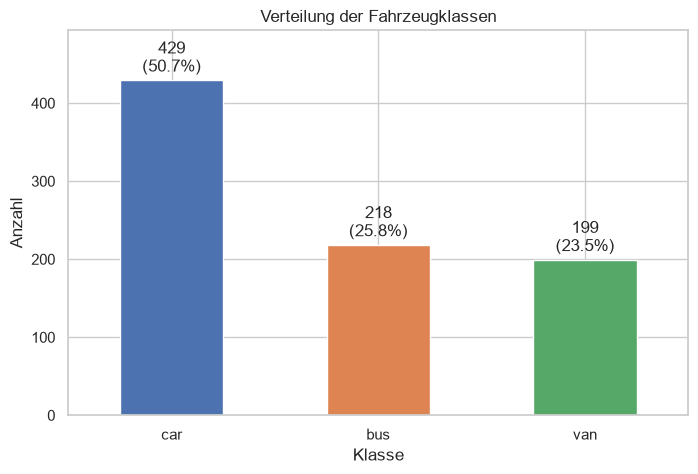

class
car    50.7
bus    25.8
van    23.5
Name: proportion, dtype: float64

In [22]:
# Klassenverteilung
counts = df["class"].value_counts()
ax = counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])

# Prozentuale Werte über den Balken einfügen
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f"{int(height)}\n({percentage:.1f}%)",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 3),
                textcoords='offset points')

ax.set_title("Verteilung der Fahrzeugklassen")
ax.set_xlabel("Klasse")
ax.set_ylabel("Anzahl")
plt.ylim(0, max(counts.values) * 1.15)  # Etwas Platz oben für die Schrift lassen
plt.xticks(rotation=0)
plt.savefig('../reports/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Ausgabe der exakten Prozentwerte als Tabelle
df["class"].value_counts(normalize=True).round(3) * 100

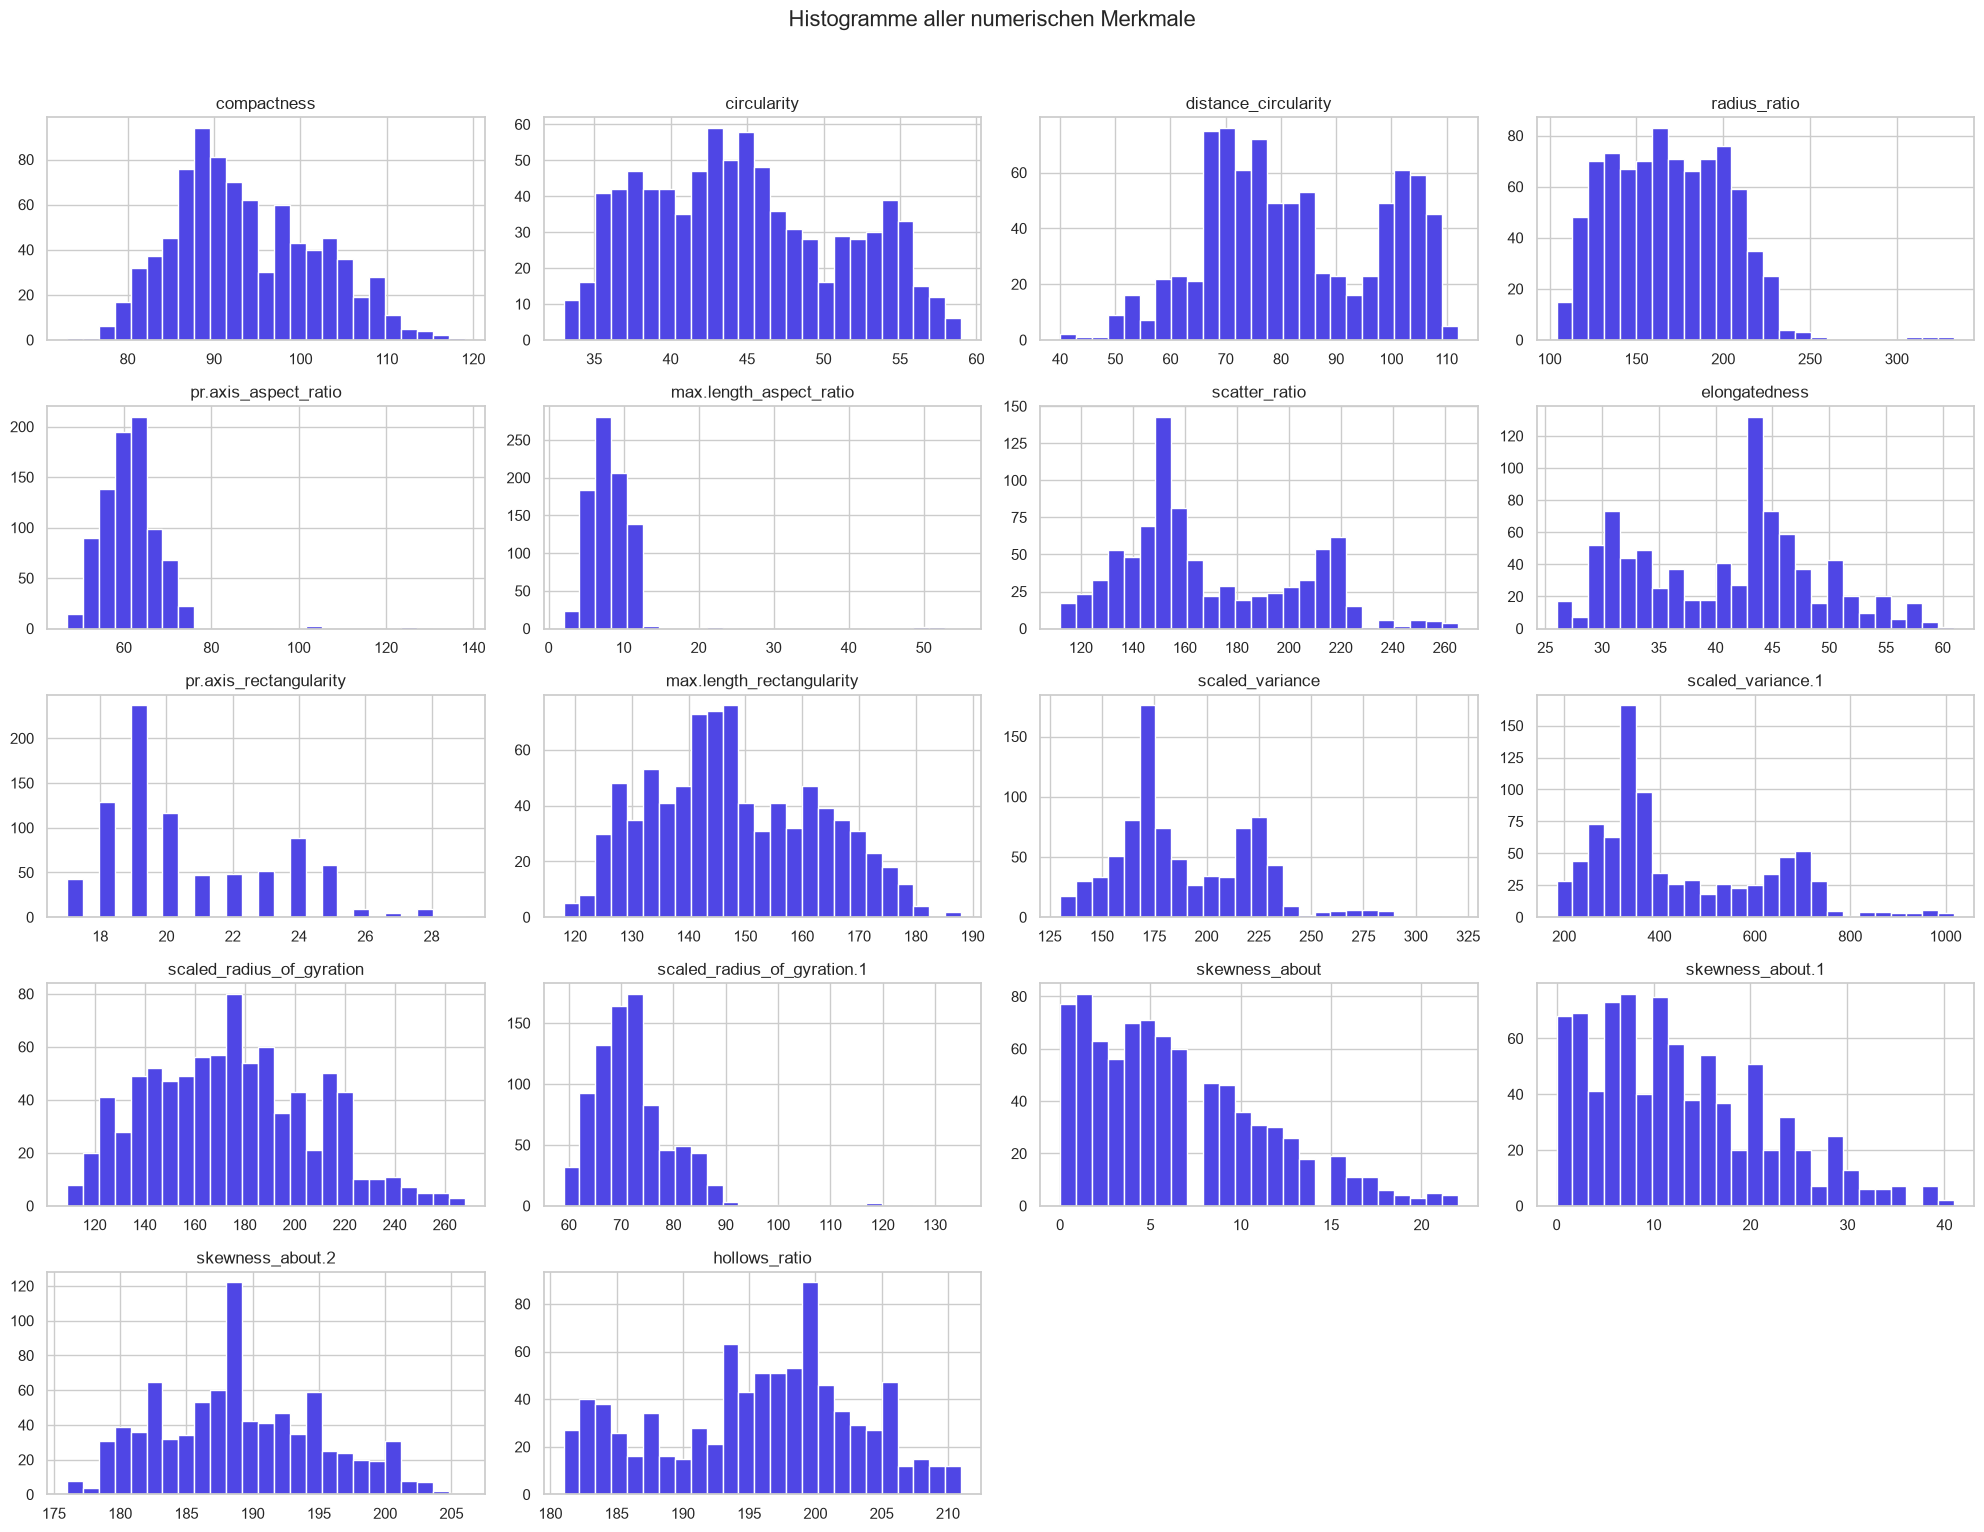

In [23]:
# Histogramme aller numerischen Merkmale -- zeigt Verteilungsform, Schiefe und
# grobe Wertebereiche auf einen Blick (wie in der Datenexploration des Dozenten)
df.drop(columns="class").hist(figsize=(20, 15), bins=25, color="#4F46E5", edgecolor="white")
plt.suptitle("Histogramme aller numerischen Merkmale", y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/histigramm.png', dpi=300, bbox_inches='tight')
plt.show()

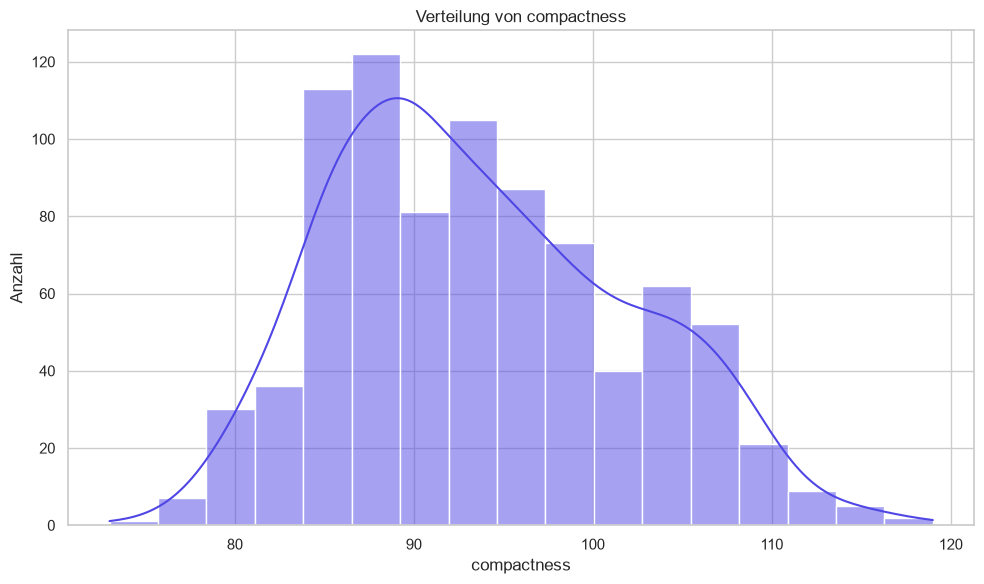

In [24]:
# Einzelnes Merkmal genauer betrachtet, inkl. KDE-Kurve
plt.figure(figsize=(10, 6))
sns.histplot(df["compactness"], kde=True, color="#4F46E5")
plt.title("Verteilung von compactness")
plt.xlabel("compactness")
plt.ylabel("Anzahl")
plt.tight_layout()
plt.savefig('../reports/figures/Verteilung_von_compactness.png', dpi=300, bbox_inches='tight')
plt.show()

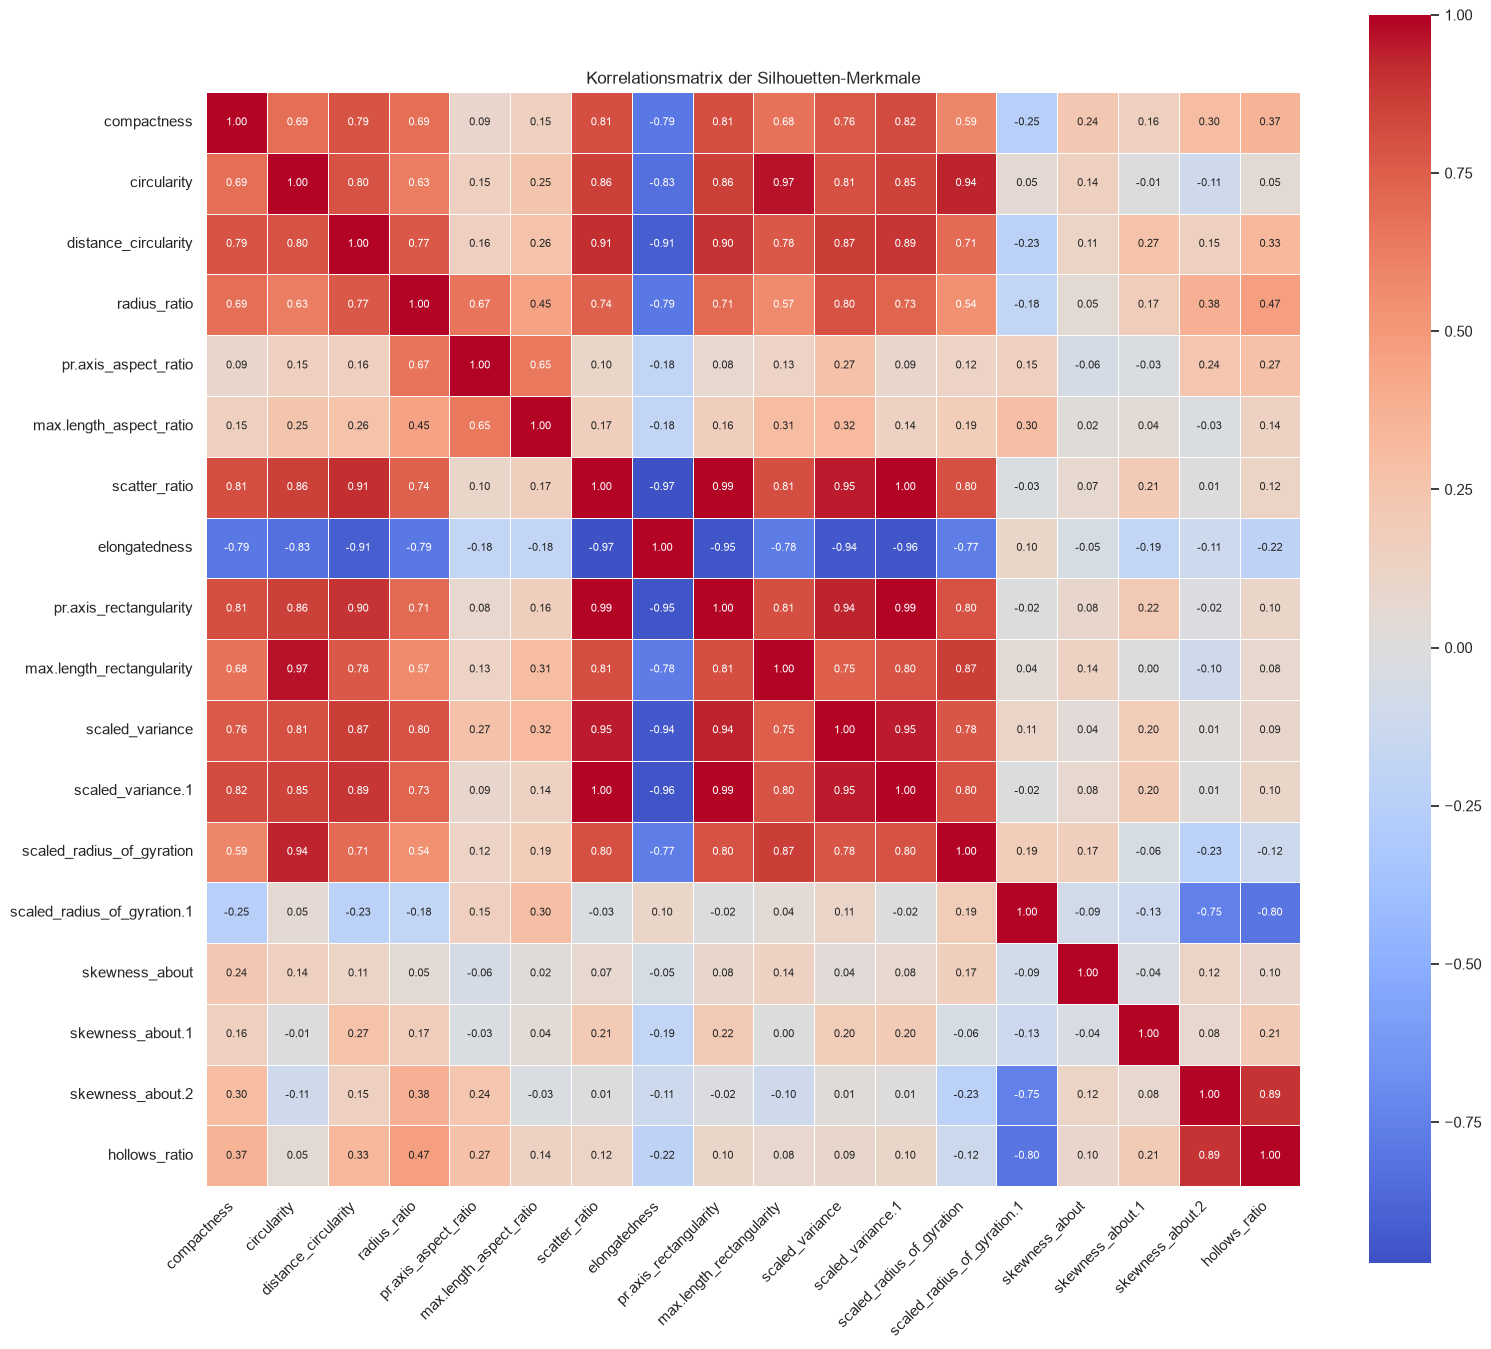

In [25]:
# Korrelationsmatrix mit Zahlenwerten in jedem Quadrat
corr = df.drop(columns="class").corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    annot=True,            # Schaltet die Anzeige der Zahlen ein
    fmt=".2f",             # Rundet auf 2 Nachkommastellen
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}  # Schriftgröße der Zahlen anpassen
)

plt.title("Korrelationsmatrix der Silhouetten-Merkmale")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

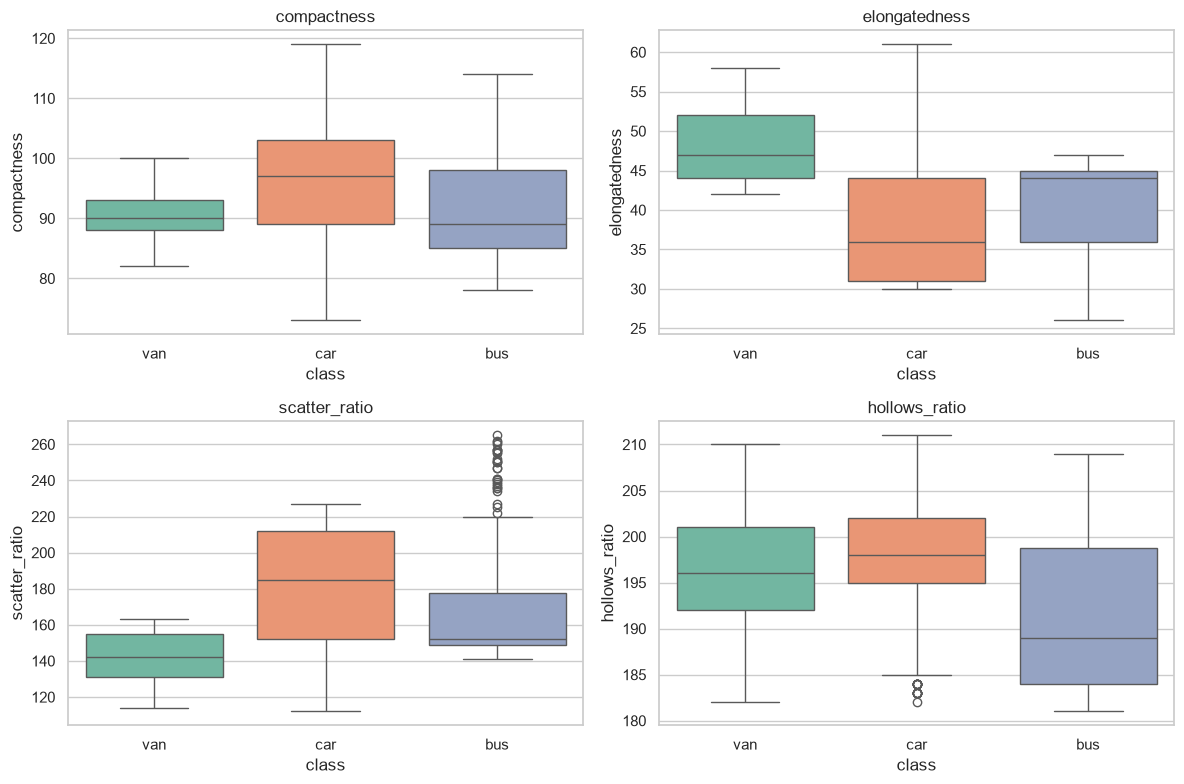

In [26]:
# Verteilung ausgewählter Merkmale je Klasse
features_to_plot = ["compactness", "elongatedness", "scatter_ratio", "hollows_ratio"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.ravel(), features_to_plot):
    sns.boxplot(data=df, x="class", y=feat, hue="class", palette="Set2", legend=False, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.savefig('../reports/figures/box_plot.png', dpi=300, bbox_inches='tight')
plt.show()

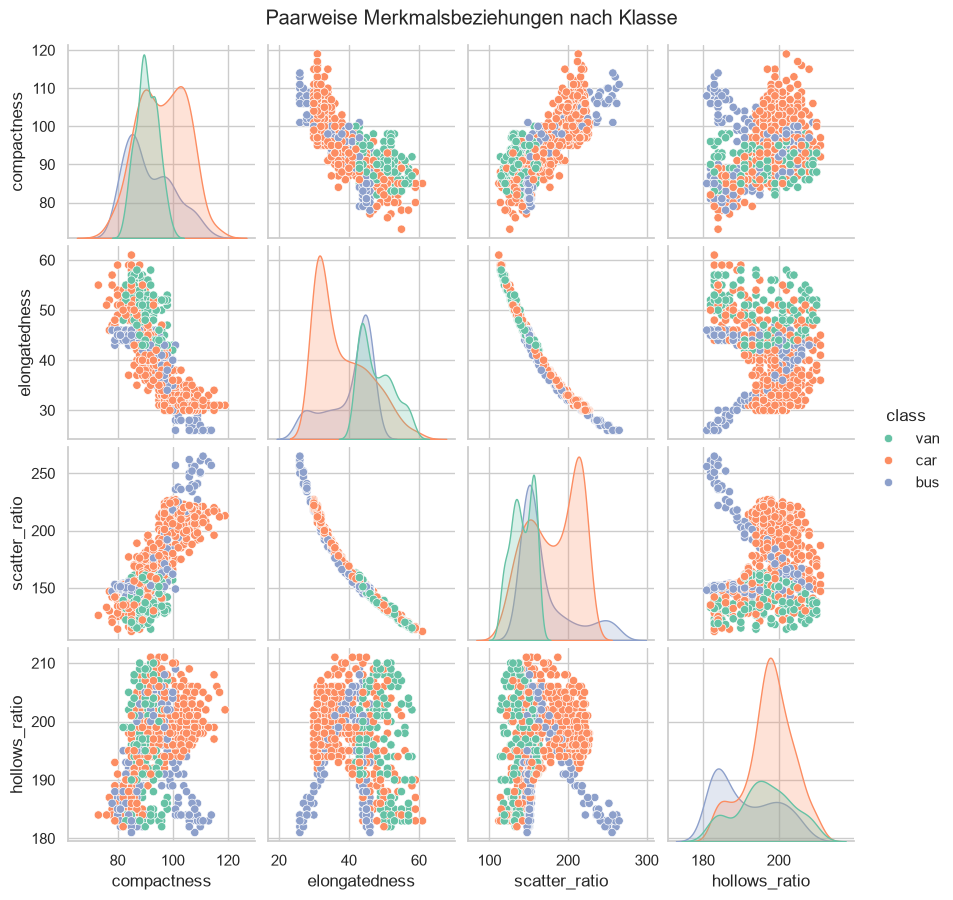

In [27]:
# Paarweise Beziehungen zwischen den trennschärfsten Merkmalen
sns.pairplot(df, vars=["compactness", "elongatedness", "scatter_ratio", "hollows_ratio"],
             hue="class", palette="Set2", diag_kind="kde", height=2.2)
plt.suptitle("Paarweise Merkmalsbeziehungen nach Klasse", y=1.02)
plt.savefig('../reports/figures/paarweise.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
X = df.drop(columns="class") #Trennt die Eingabemerkmale (Features) vom Zielwert. X enthält alle 18 numerischen Messwerte.
y = df["class"] # y ist der Zielwert (Target), den das Modell vorhersagen soll (ob ein Fahrzeug ein car, bus oder van ist).

# Stratifizierter Split, damit Klassenanteile in Train- und Testset erhalten bleiben
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
y_train.value_counts(normalize=True).round(3)

Train: (676, 18)  Test: (170, 18)


class
car    0.507
bus    0.257
van    0.235
Name: proportion, dtype: float64

In [16]:
# Imputation fehlender Werte: Median je Spalte, NUR auf Basis der Trainingsdaten berechnet
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

# Kontrolle: keine fehlenden Werte mehr
print("Fehlende Werte Train nach Imputation:", X_train_imputed.isna().sum().sum())
print("Fehlende Werte Test nach Imputation:", X_test_imputed.isna().sum().sum())


Fehlende Werte Train nach Imputation: 0
Fehlende Werte Test nach Imputation: 0


In [30]:
import os

# 1. Sicherstellen, dass der Ordner existiert
os.makedirs('../data/processed', exist_ok=True)

# 2. X und y wieder zu einem bereinigten Gesamt-DataFrame zusammenfügen
df_clean = pd.concat([X_train_imputed, X_test_imputed])
df_clean['class'] = pd.concat([y_train, y_test])

# 3. Als CSV-Datei abspeichern
df_clean.to_csv('../data/processed/vehicle_clean.csv', index=False)

print("Bereinigte Daten erfolgreich unter 'data/processed/vehicle_clean.csv' gespeichert!")

Bereinigte Daten erfolgreich unter 'data/processed/vehicle_clean.csv' gespeichert!


In [17]:
# Standardisierung: Mittelwert 0, Standardabweichung 1
# -- WICHTIG: scaler wird nur auf den (bereits imputierten) Trainingsdaten "gefittet",
# um Data Leakage aus dem Testset zu vermeiden
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Logistische Regression ---
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg_cv_scores = cross_val_score(logreg, X_train_scaled, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)

# --- Support Vector Machine ---
svm = SVC(kernel="rbf", random_state=RANDOM_STATE)
svm_cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)

# --- K-Nearest Neighbors ---
knn = KNeighborsClassifier(n_neighbors=5)
knn_cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)

# AdaBoost initialisieren (Basislerner sind standardmäßig Decision Stumps)
ada = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)
ada_cv_scores = cross_val_score(ada, X_train_scaled, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)

# Ergebnisse ausgeben
print(f"Logistische Regression -- CV F1 (gewichtet): {logreg_cv_scores.mean():.3f} (+/- {logreg_cv_scores.std():.3f})")
print(f"Random Forest          -- CV F1 (gewichtet): {rf_cv_scores.mean():.3f} (+/- {rf_cv_scores.std():.3f})")
print(f"Support Vector Machine -- CV F1 (gewichtet): {svm_cv_scores.mean():.3f} (+/- {svm_cv_scores.std():.3f})")
print(f"K-Nearest Neighbors    -- CV F1 (gewichtet): {knn_cv_scores.mean():.3f} (+/- {knn_cv_scores.std():.3f})")
print(f"AdaBoost               -- CV F1 (gewichtet): {ada_cv_scores.mean():.3f} (+/- {ada_cv_scores.std():.3f})")




Logistische Regression -- CV F1 (gewichtet): 0.941 (+/- 0.011)
Random Forest          -- CV F1 (gewichtet): 0.954 (+/- 0.009)
Support Vector Machine -- CV F1 (gewichtet): 0.962 (+/- 0.018)
K-Nearest Neighbors    -- CV F1 (gewichtet): 0.898 (+/- 0.031)
AdaBoost               -- CV F1 (gewichtet): 0.845 (+/- 0.030)


In [19]:
from sklearn.model_selection import GridSearchCV

# --- Logistische Regression -------------------------------------------------
logreg_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs"],  # unterstuetzt L2-Regularisierung (sklearn-Default) fuer Multiclass
}
gs_logreg = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    logreg_grid, cv=cv, scoring="f1_weighted", n_jobs=-1
)
gs_logreg.fit(X_train_scaled, y_train)

# --- Random Forest -----------------------------------------------------------
rf_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, cv=cv, scoring="f1_weighted", n_jobs=-1
)
gs_rf.fit(X_train_scaled, y_train)

# --- Support Vector Machine ---------------------------------------------------
svm_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf"],
}
gs_svm = GridSearchCV(
    SVC(random_state=RANDOM_STATE),
    svm_grid, cv=cv, scoring="f1_weighted", n_jobs=-1
)
gs_svm.fit(X_train_scaled, y_train)

# --- Zusammenfassung: Baseline vs. getuned -----------------------------------
tuning_summary = pd.DataFrame({
    "Modell": ["Logistische Regression", "Random Forest", "SVM (RBF)"],
    "CV F1-weighted (Baseline)": [logreg_cv_scores.mean(), rf_cv_scores.mean(), svm_cv_scores.mean()],
    "CV F1-weighted (getuned)": [gs_logreg.best_score_, gs_rf.best_score_, gs_svm.best_score_],
    "Beste Parameter": [gs_logreg.best_params_, gs_rf.best_params_, gs_svm.best_params_],
}).round(4)

tuning_summary

,Modell,CV F1-weighted (Baseline),CV F1-weighted (getuned),Beste Parameter
0,Logistische Regression,0.9410,0.9570,"{'C': 100, 'solver': 'lbfgs'}"
1,Random Forest,0.9543,0.9587,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
2,SVM (RBF),0.9618,0.9778,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"


================ Support Vector Machine (getuned) ================
              precision    recall  f1-score   support

         bus      0.978     1.000     0.989        44
         car      0.988     0.977     0.982        86
         van      0.975     0.975     0.975        40

    accuracy                          0.982       170
   macro avg      0.980     0.984     0.982       170
weighted avg      0.982     0.982     0.982       170



================ Random Forest (getuned) ================
              precision    recall  f1-score   support

         bus      0.956     0.977     0.966        44
         car      0.976     0.930     0.952        86
         van      0.907     0.975     0.940        40

    accuracy                          0.953       170
   macro avg      0.946     0.961     0.953       170
weighted avg      0.954     0.953     0.953       170



================ Logistic Regression (getuned) ================
              precision    recall  f1-score  

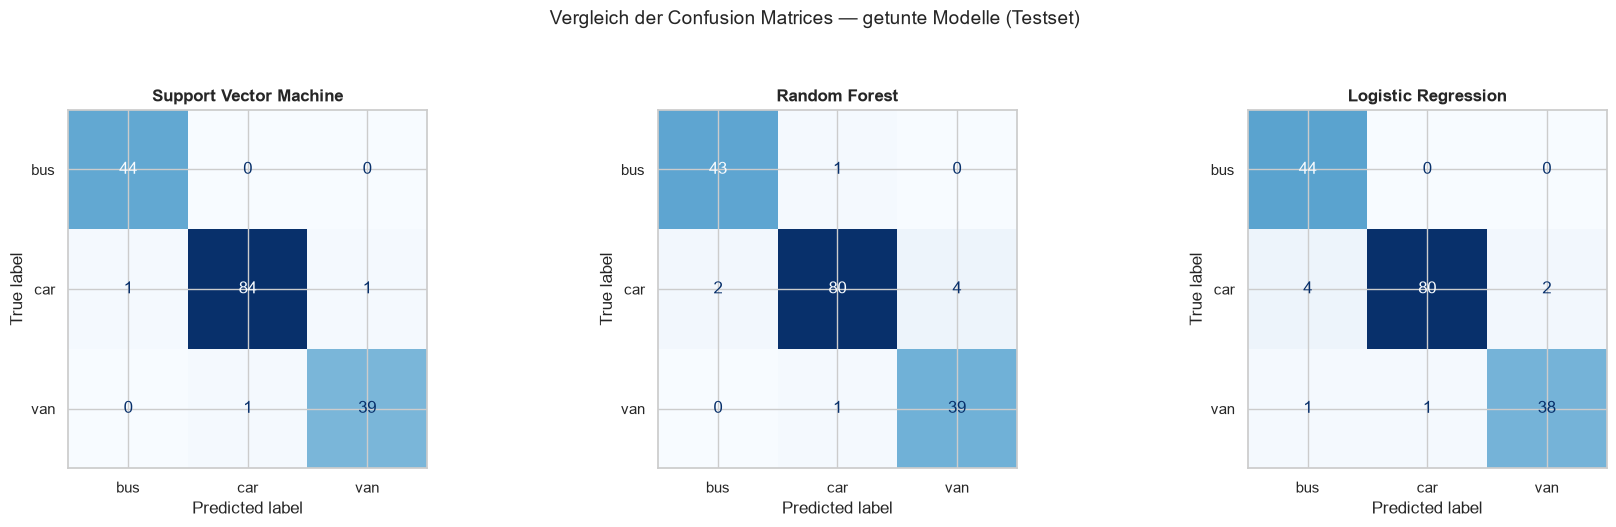

In [28]:
# Die getunten Modelle aus dem GridSearchCV (best_estimator_) sind bereits auf dem
# gesamten Trainingsset refittet (GridSearchCV(refit=True) ist der Default) --
# hier daher direkt zur Evaluation auf dem bisher ungesehenen Testset verwenden.
logreg = gs_logreg.best_estimator_
rf = gs_rf.best_estimator_
svm = gs_svm.best_estimator_

# Dictionary mit den drei getunten Top-Modellen
top3_models = {
    "Support Vector Machine": (svm, svm.predict(X_test_scaled)),
    "Random Forest": (rf, rf.predict(X_test_scaled)),
    "Logistic Regression": (logreg, logreg.predict(X_test_scaled))
}

# 2. Classification Reports ausgeben
for name, (model, y_pred) in top3_models.items():
    print(f"================ {name} (getuned) ================")
    print(classification_report(y_test, y_pred, digits=3))
    print("\n")

# 3. Confusion Matrices nebeneinander visualisieren
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (model, y_pred)) in zip(axes, top3_models.items()):
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}", fontsize=12, fontweight="bold")

plt.suptitle("Vergleich der Confusion Matrices \u2014 getunte Modelle (Testset)", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('../reports/figures/ConfusionMatrixDisplay.png', dpi=300, bbox_inches='tight')
plt.show()

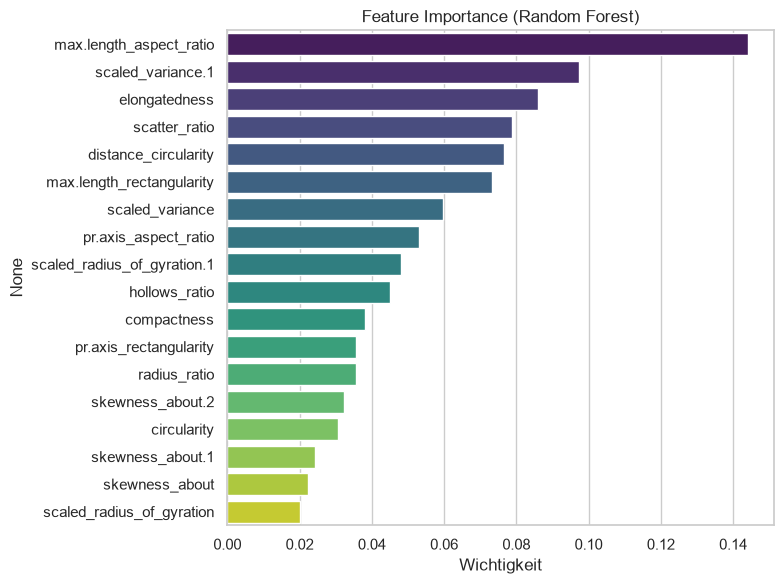

max.length_aspect_ratio        0.144110
scaled_variance.1              0.097366
elongatedness                  0.085955
scatter_ratio                  0.078897
distance_circularity           0.076599
max.length_rectangularity      0.073237
scaled_variance                0.059588
pr.axis_aspect_ratio           0.052962
scaled_radius_of_gyration.1    0.048053
hollows_ratio                  0.044884
compactness                    0.038011
pr.axis_rectangularity         0.035588
radius_ratio                   0.035489
skewness_about.2               0.032334
circularity                    0.030587
skewness_about.1               0.024115
skewness_about                 0.022210
scaled_radius_of_gyration      0.020016
dtype: float64

In [29]:
# Feature Importance des Random Forest -- zeigt, welche Silhouetten-Merkmale
# am meisten zur Unterscheidung der Klassen beitragen
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="viridis", legend=False)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Wichtigkeit")
plt.tight_layout()
plt.savefig('../reports/figures/importances.png', dpi=300, bbox_inches='tight')
plt.show()

importances